Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/nhpp_20251208-165214") 
# checkpoints/mixer_tpp_20250912-125450
 # "../checkpoints/mixer_tpp_20250907-112659"
 # /checkpoints/mixer_tpp_20250825-114639 /checkpoints/rtpp_20250824-214315
 # checkpoints/mixer_tpp_20250819-143535 checkpoints/mixer_tpp_20250819-143210
#  checkpoints/rtpp_20250819-142340
checkpoint_path = checkpoint_dir / "last_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'nhpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'proportional', 'bg_model_cfg': {'d_feature': 1, 'scale_init': 200.0}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dim': 1, 'epochs': 1000, 'save_dir': 'checkpoints/nhpp_20251208-165214', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.06001083552837372, 'tau_min': 5.3589729986924795e-08, 'tau_max': 17.831666946411133, 'tau_q05': 0.002222222276031971, 'tau_q025': 1.1896516298293136e-05, 'mag_mean': -1.6526764631271362, 'time_max': 900.0,

OptimizedModule(
  (_orig_mod): NHPP(
    (bg_model): ProportionalBGModel(
      (fc): Linear(in_features=1, out_features=1, bias=False)
    )
  )
)

In [5]:
model.bg_model._scale

tensor(73.5812, device='cuda:0', grad_fn=<ExpBackward0>)

## Loading the catalog

In [6]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [7]:
catalog_ds.full_sequence

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92316, 1],
  time_series_times: [92316]
)

In [81]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

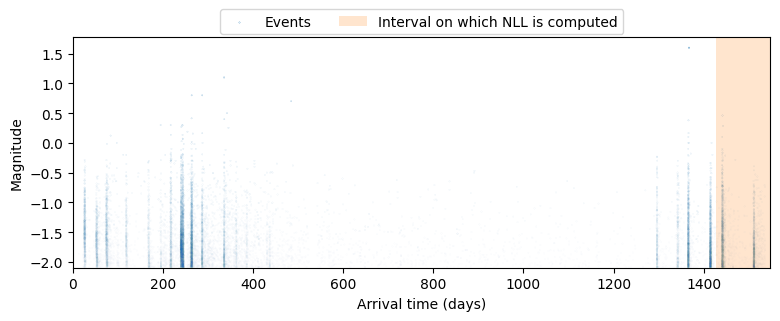

In [12]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [9]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 14869],
  arrival_times: [1, 14869],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 14869],
  input_mask: [1, 14869],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 14869],
  type_seq: [1, 14869],
  mag: [1, 14869],
  loc: [1, 14869, 2],
  depth: [1, 14869],
  time_series: [1, 54001, 1],
  time_series_times: [1, 54001]
)

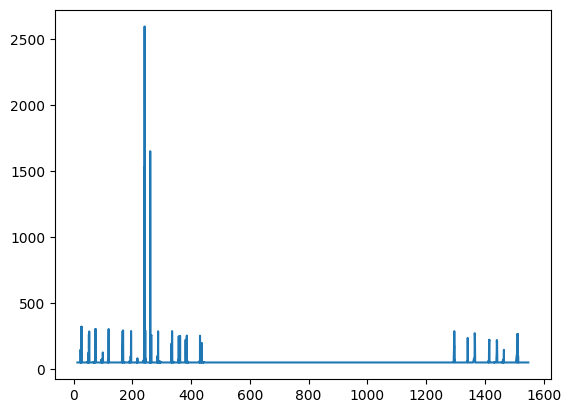

In [10]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),f_intensity.reshape(-1).detach().cpu().numpy())
plt.savefig(checkpoint_dir/'induced_intensity.png')

In [ ]:
context = model.get_context(test_batch)
inter_time_dist = model.get_inter_time_dist(context)
log_h_intensity = inter_time_dist.log_hazard(test_batch.inter_times)
h_intensity = torch.exp(log_h_intensity)
plt.plot(test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),h_intensity.reshape(-1).detach().cpu().numpy())

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [11]:
t_forecast = 1460 # 4000 13000
duration = 20 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

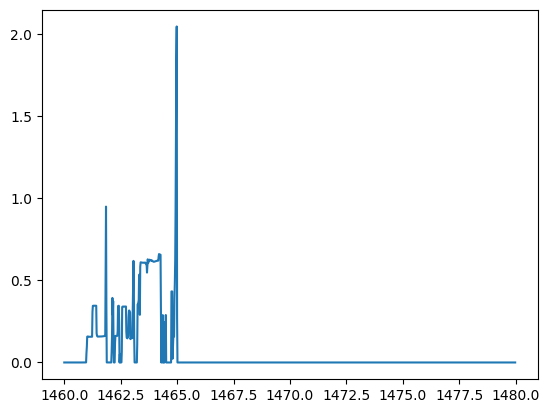

In [9]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.plot(future_time_series_times, future_time_series.reshape(-1).detach().cpu().numpy())

## Generate the forecast

In [12]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [12]:
torch.mean(past_batch.inter_times)

tensor(0.0682)

In [13]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [16]:
# torch.backends.cudnn.enabled = False

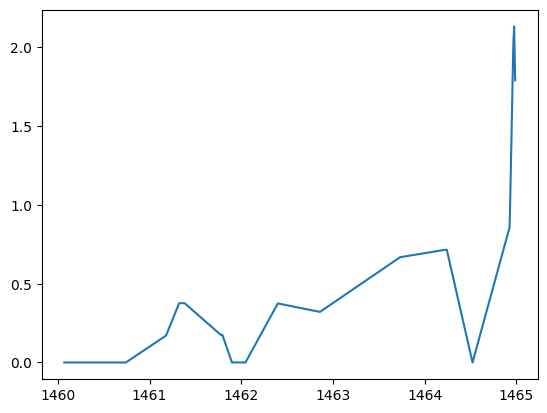

In [20]:
# ...existing code...
mask = (test_batch.arrival_times >= 1460) & (test_batch.arrival_times <= 1465)
out_sel = out[mask]
plt.plot(test_batch.arrival_times[mask].reshape(-1).detach().cpu().numpy(), out_sel.reshape(-1).detach().cpu().numpy())

In [84]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [86]:
import torch
with torch.no_grad():
    model.bg_model.raw_weight.copy_(torch.tensor([[10]], device='cuda'))

In [87]:
model.nll_loss(train_batch)

w: tensor([[10.0000]], device='cuda:0', grad_fn=<SoftplusBackward0>)
log_intensity: tensor([[-18.4207, -18.4207, -18.4207,  ..., -18.4207, -18.4207, -18.4207]],
       device='cuda:0', grad_fn=<LogBackward0>),


tensor([[229.8238]], device='cuda:0', grad_fn=<DivBackward0>)

In [23]:
set_seed(4) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

In [24]:
all_forecasts

[Sequence(
   inter_times: [253],
   arrival_times: [252],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [252]
 ),
 Sequence(
   inter_times: [434],
   arrival_times: [433],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [433]
 ),
 Sequence(
   inter_times: [204],
   arrival_times: [203],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [203]
 ),
 Sequence(
   inter_times: [158],
   arrival_times: [157],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [157]
 ),
 Sequence(
   inter_times: [428],
   arrival_times: [427],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [427]
 ),
 Sequence(
   inter_times: [264],
   arrival_times: [263],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [263]
 ),
 Sequence(
   inter_times: [388],
   arrival_times: [387],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [387]
 ),
 Sequence(
   inter_times: 

(array([2.000e+01, 2.590e+02, 7.980e+02, 1.604e+03, 2.111e+03, 1.633e+03,
        9.590e+02, 6.470e+02, 5.020e+02, 3.840e+02, 2.830e+02, 2.080e+02,
        1.530e+02, 1.130e+02, 8.200e+01, 6.000e+01, 4.400e+01, 3.200e+01,
        3.300e+01, 1.900e+01, 1.500e+01, 1.500e+01, 8.000e+00, 3.000e+00,
        8.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 3.000e+00, 1.000e+00]),
 array([  45.        ,   84.33333333,  123.66666667,  163.        ,
         202.33333333,  241.66666667,  281.        ,  320.33333333,
         359.66666667,  399.        ,  438.33333333,  477.66666667,
         517.        ,  556.33333333,  595.66666667,  635.        ,
         674.33333333,  713.66666667,  753.        ,  792.33333333,
         831.66666667,  871.        ,  910.33333333,  949.66666667,
         989.        , 1028.33333333, 1067.66666667, 1107.        ,
        1146.33333333, 1185.66666667, 1225.        ]),
 <BarContainer object of 30 artists>)

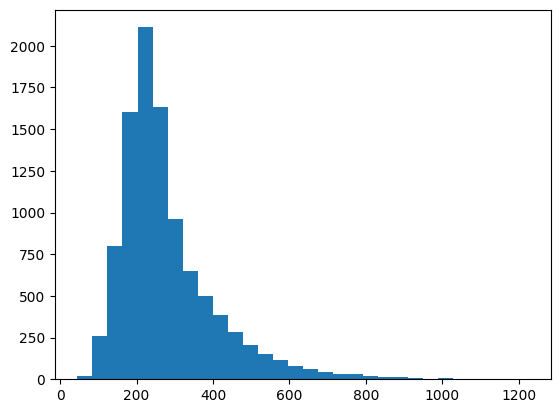

In [25]:
len_list = [len(f.arrival_times) for f in all_forecasts]
plt.hist(len_list, bins=30)

In [26]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [320, 3319, 3614, 4030, 5914, 6648, 6905, 7213, 9175]
Number of forecasts with zero inter_times: 9


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [27]:
# importlib.reload(src.utils.visualization)

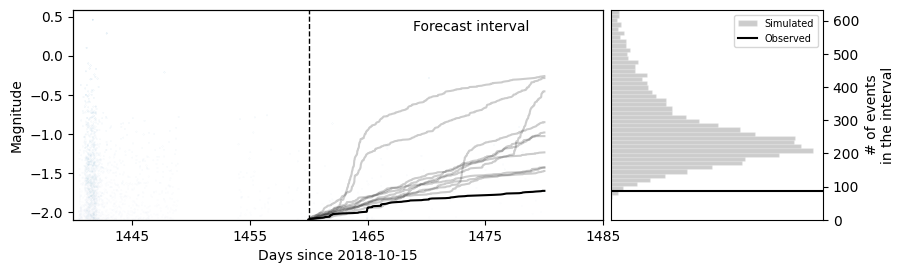

In [28]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [29]:
import  src.utils.catalog_tests as catalog_tests

In [30]:
test_seq

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

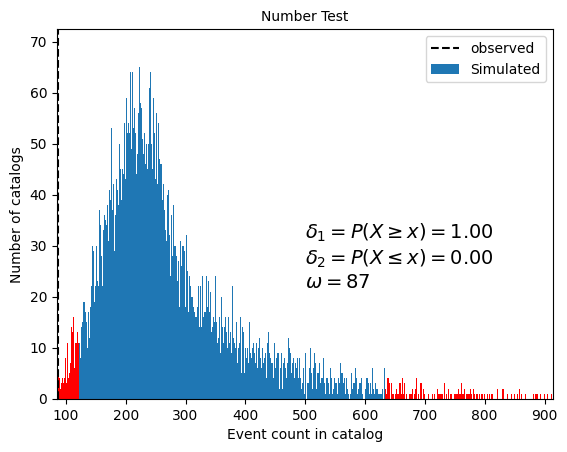

In [31]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [32]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [33]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:423: SyntaxWarning: invalid escape sequence '\l'
  ylabel = plot_args.get('ylabel', '$P(X \leq x)$')
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1106: SyntaxWarning: invalid escape sequence '\d'
  '$\delta_1 = P(X \geq x) = {:.2f}$\n$\delta_2 = P(X \leq x) = {:.2f}$\n$\omega = {:d}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1113: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \leq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1205: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1213: SyntaxWarning: invalid escape sequence '\g'
  ax.annotate('$\gamma = P(X \geq x) = {:.2f}$\n$\omega = {:.2f}$'
/root/miniconda3/lib/python3.12/site-packages/csep/utils/plots.py:1281: Syntax

IndexError: index -1 is out of bounds for axis 0 with size 0

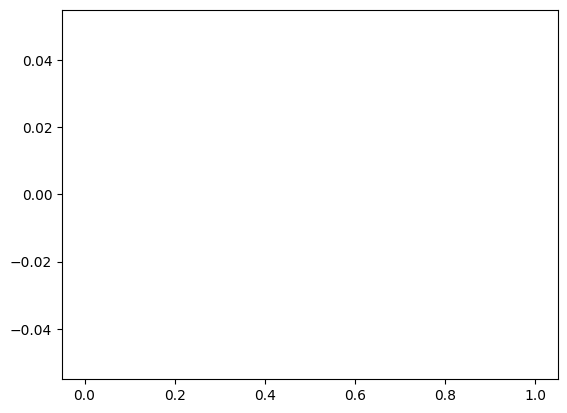

In [34]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')